## Importing Libraries

In [138]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

## Importing and preprocessing the dataset

In [139]:
df = pd.read_excel("clickbait_hybrid.xlsx")
df.dropna(inplace=True)
df.rename(columns={'clickbait': 'label'}, inplace=True)
df['label'] = df['label'].map({0: 'real', 1: 'clickbait'})

In [140]:
print(df.shape)
df.head()

(350, 2)


,thumbnails,label
0,এই ব্যাপারগুলো হতে যাচ্ছে খুব তাড়াতাড়ি,clickbait
1,বদলে যাবে আপনার জীবন এই কাজগুলো করলে,clickbait
2,আমাদের উপরে কি ভয়ংকর বিপদ আসতে যাচ্ছে,clickbait
3,রোজা রাখার ফলে ক্যান্সার সেল ধ্বংস হয়,real
4,কোন দেশে যাব পড়তে,clickbait


## Train-Test Split

In [141]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['thumbnails'], df['label'], test_size=0.2, random_state=42, stratify=df['label']) 

In [142]:
y_train.value_counts(normalize=True) # Used Stratify for proportional distribution

label
real         0.507143
clickbait    0.492857
Name: proportion, dtype: float64

In [143]:
y_test.value_counts(normalize=True) # Used Stratify for proportional distribution

label
real         0.514286
clickbait    0.485714
Name: proportion, dtype: float64

In [144]:
print(f"Train : {len(X_train)}, Test : {len(X_test)}")

Train : 280, Test : 70


## Feature Extraction with TF-IDF

In [145]:
# import re
# def bangla_tokenizer(text):
#     # Extract only Bangla words
#     text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)
#     words = re.findall(r'[\u0980-\u09FF]+', text)
#     return words

In [146]:
import re
import unicodedata

# Basic Bangla stopwords (you can expand this)
bangla_stopwords = set([
    "এই", "ওই", "এটা", "ওটা", "আমি", "তুমি", "সে", "তিনি",
    "এবং", "করে", "ছিল", "হবে", "হয়", "কেন", "কি", "যে",
    "না", "তো", "একটি", "জন্য", "সাথে"
])

def normalize_bangla(text):
    # Unicode normalization
    text = unicodedata.normalize("NFKC", text)

    # Remove non-Bangla chars
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)

    # Normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def bangla_tokenizer(text):
    text = normalize_bangla(text)

    words = re.findall(r'[\u0980-\u09FF]+', text)

    # Remove stopwords
    words = [w for w in words if w not in bangla_stopwords]

    return words

In [147]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# vectorizer = TfidfVectorizer(    
#     tokenizer=bangla_tokenizer,
#     token_pattern=None,
#     lowercase=False,
#     ngram_range=(1, 3),
#     min_df=2,
#     max_df=0.8,
#     sublinear_tf=True,
#     max_features=5000)
# X_train_vec = vectorizer.fit_transform(X_train)
# X_test_vec = vectorizer.transform(X_test)

# print(f"Feature matrix shape: {X_train_vec.shape}")

In [148]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Word-level TF-IDF
word_vectorizer = TfidfVectorizer(
    tokenizer=bangla_tokenizer,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
    max_features=4000
)

# Character-level TF-IDF (VERY powerful)
char_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    min_df=2,
    max_features=3000
)

# Fit and transform
X_train_word = word_vectorizer.fit_transform(X_train)
X_test_word = word_vectorizer.transform(X_test)

X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

# Combine features
X_train_vec = hstack([X_train_word, X_train_char])
X_test_vec = hstack([X_test_word, X_test_char])

print(f"Feature matrix shape: {X_train_vec.shape}")

Feature matrix shape: (280, 3252)


## Training Random Forest Model

In [149]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
classifier.fit(X_train_vec, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

## Evaluation of the test

In [150]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

y_pred = classifier.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 68.57%
              precision    recall  f1-score   support

   clickbait       0.73      0.56      0.63        34
        real       0.66      0.81      0.72        36

    accuracy                           0.69        70
   macro avg       0.69      0.68      0.68        70
weighted avg       0.69      0.69      0.68        70



## Plotting confusion Matrix (Random Forest)

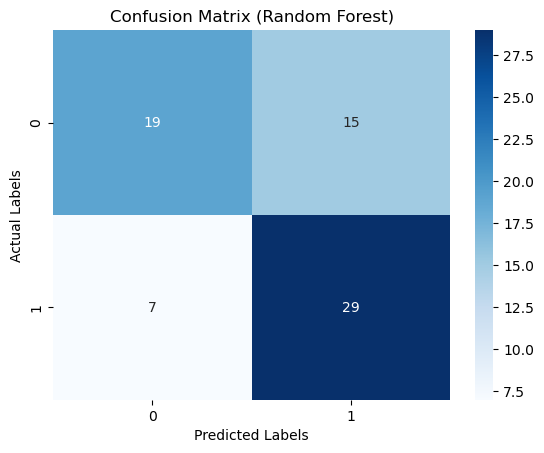

In [151]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.ylabel('Actual Labels')        # y-axis label (true values)
plt.xlabel('Predicted Labels')     # x-axis label (predicted values)
plt.show()

## Training Support Vector Machine Model

In [152]:
from sklearn.svm import SVC
svm_cl = SVC(kernel='rbf', random_state=42)
svm_cl.fit(X_train_vec, y_train)

SVC(random_state=42)

## Evaluation of the test (SVM)

In [153]:
y_pred_svm = svm_cl.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}%")
# Classification Report
print(classification_report(y_test, y_pred_svm))

Accuracy: 68.57%
              precision    recall  f1-score   support

   clickbait       0.73      0.56      0.63        34
        real       0.66      0.81      0.72        36

    accuracy                           0.69        70
   macro avg       0.69      0.68      0.68        70
weighted avg       0.69      0.69      0.68        70



## Plotting confusion Matrix (SVM)

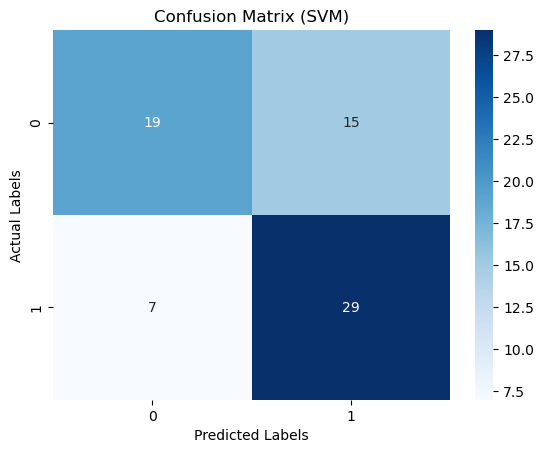

In [154]:
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (SVM)")
plt.ylabel('Actual Labels')        # y-axis label (true values)
plt.xlabel('Predicted Labels')     # x-axis label (predicted values)
plt.show()